In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("aug_train.csv")
df.head(10)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0
5,21651,city_176,0.764,NaN,Has relevent experience,Part time course,Graduate,STEM,11,NaN,NaN,1,24,1.0
6,28806,city_160,0.920,Male,Has relevent experience,no_enrollment,High School,NaN,5,50-99,Funded Startup,1,24,0.0
7,402,city_46,0.762,Male,Has relevent experience,no_enrollment,Graduate,STEM,13,<10,Pvt Ltd,>4,18,1.0
8,27107,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,7,50-99,Pvt Ltd,1,46,1.0
9,699,city_103,0.920,NaN,Has relevent experience,no_enrollment,Graduate,STEM,17,10000+,Pvt Ltd,>4,123,0.0


# Data Cleaning

As detected by eda engine
enrollee_id should be dropped as they are highly cardinal and not info worthy

In [3]:
df['gender'].value_counts() #needs fixing

gender
Male      13221
Female     1238
Other       191
Name: count, dtype: int64

In [4]:
df["gender"] = df["gender"].fillna("Unknown")

In [5]:
df["major_discipline"].value_counts()


major_discipline
STEM               14492
Humanities           669
Other                381
Business Degree      327
Arts                 253
No Major             223
Name: count, dtype: int64

In [6]:
df['major_discipline'] = df['major_discipline'].fillna('Not_Applicable')
df["education_level"] = df["education_level"].fillna("Unknown")

In [7]:
df["experience"].value_counts()

experience
>20    3286
5      1430
4      1403
3      1354
6      1216
2      1127
7      1028
10      985
9       980
8       802
15      686
11      664
14      586
1       549
<1      522
16      508
12      494
13      399
17      342
19      304
18      280
20      148
Name: count, dtype: int64

In [8]:
df["company_type"].value_counts()

company_type
Pvt Ltd                9817
Funded Startup         1001
Public Sector           955
Early Stage Startup     603
NGO                     521
Other                   121
Name: count, dtype: int64

In [9]:
df["experience"] = (df["experience"]
                    .replace({"<1": "0", ">20": "21"})
                    .astype(float))

df["experience"] = df["experience"].fillna(df["experience"].median())

In [10]:
df["company_size"] = df["company_size"].fillna("Unknown")
df["company_size"] = df["company_size"].replace({"10/49": "10-49"})

In [11]:
df["company_type"] = df["company_type"].fillna("Unknown")
df["last_new_job"] = (df["last_new_job"]
                      .replace({">4": "5", "never": "0"})
                      .astype(float))
df["last_new_job"] = df["last_new_job"].fillna(df["last_new_job"].mode()[0])

# Handle Right-Skew: Log transform for training_hours
df["training_hours_log"] = np.log1p(df["training_hours"])

# Handle Left-Skew: Binning city_development_index
bins = [0.0, 0.6, 0.85, 1.0]
labels = ["Low Development", "Medium Development", "High Development"]
df["city_development_binned"] = pd.cut(df["city_development_index"], bins=bins, labels=labels)

df = df.drop(columns=["enrollee_id"])

### Data Cleaning Summary: What we did and why

* We dropped `enrollee_id`. It’s just a random ID number used for tracking and doesn't tell us anything about why someone might want to change jobs.
* **Saving Data instead of Deleting It:** Columns like `gender`, `company_size`, and `company_type` had a *lot* of missing blank spaces (up to 30% of the data!). Instead of deleting those rows and losing a massive chunk of our workforce data, we safely labeled them as `"Unknown"` or `"Not_Applicable"`.
* **Translating Text into Math:** The `experience` and `last_new_job` columns had text mixed in with numbers (like `>20`, `<1`, and `never`). We converted these into actual numbers (`21`, `0`, and `0`) so we can calculate averages and run correlations later. We filled the tiny amount of missing blanks here with the median/mode.
* **Fixing Typos:** We caught a formatting typo in `company_size` and changed `10/49` to `10-49` so all the categories match up perfectly.
* *Training Hours:* A few people took an extreme amount of training, which skewed our data heavily to the right. We applied a **Log Transformation** to reign in those massive outliers and make the distribution look more like a normal bell curve.
* *City Development:* Because most of our candidates live in highly developed cities (causing a heavy left-skew), we grouped the exact index numbers into clean, readable categories: `"Low"`, `"Medium"`, and `"High"`.

# Visualization

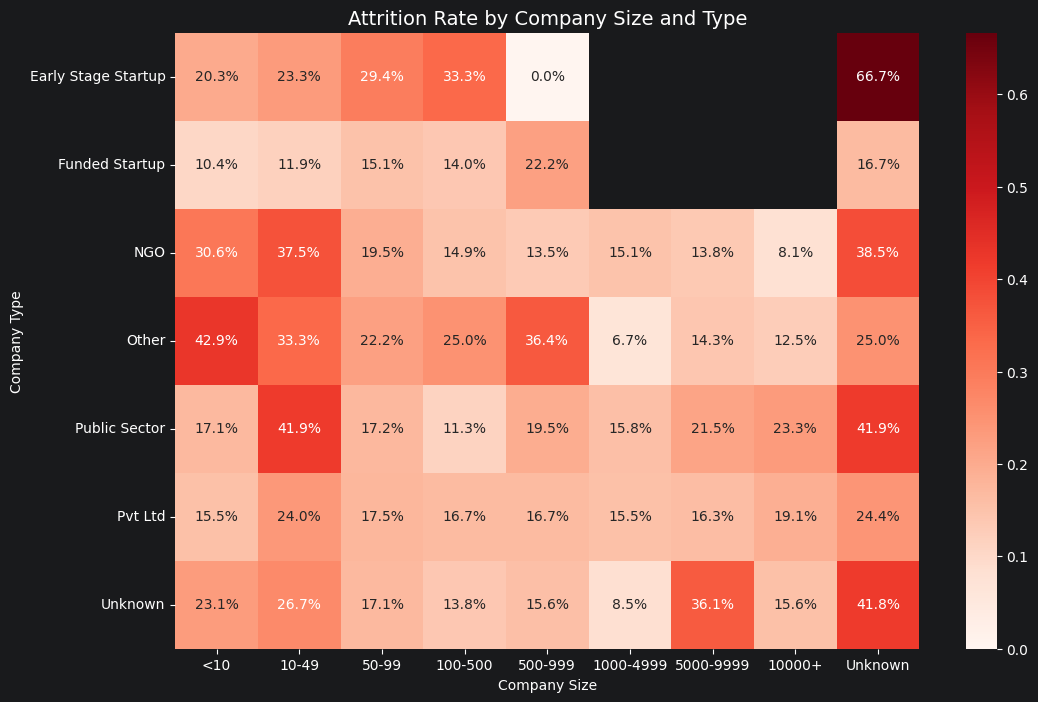

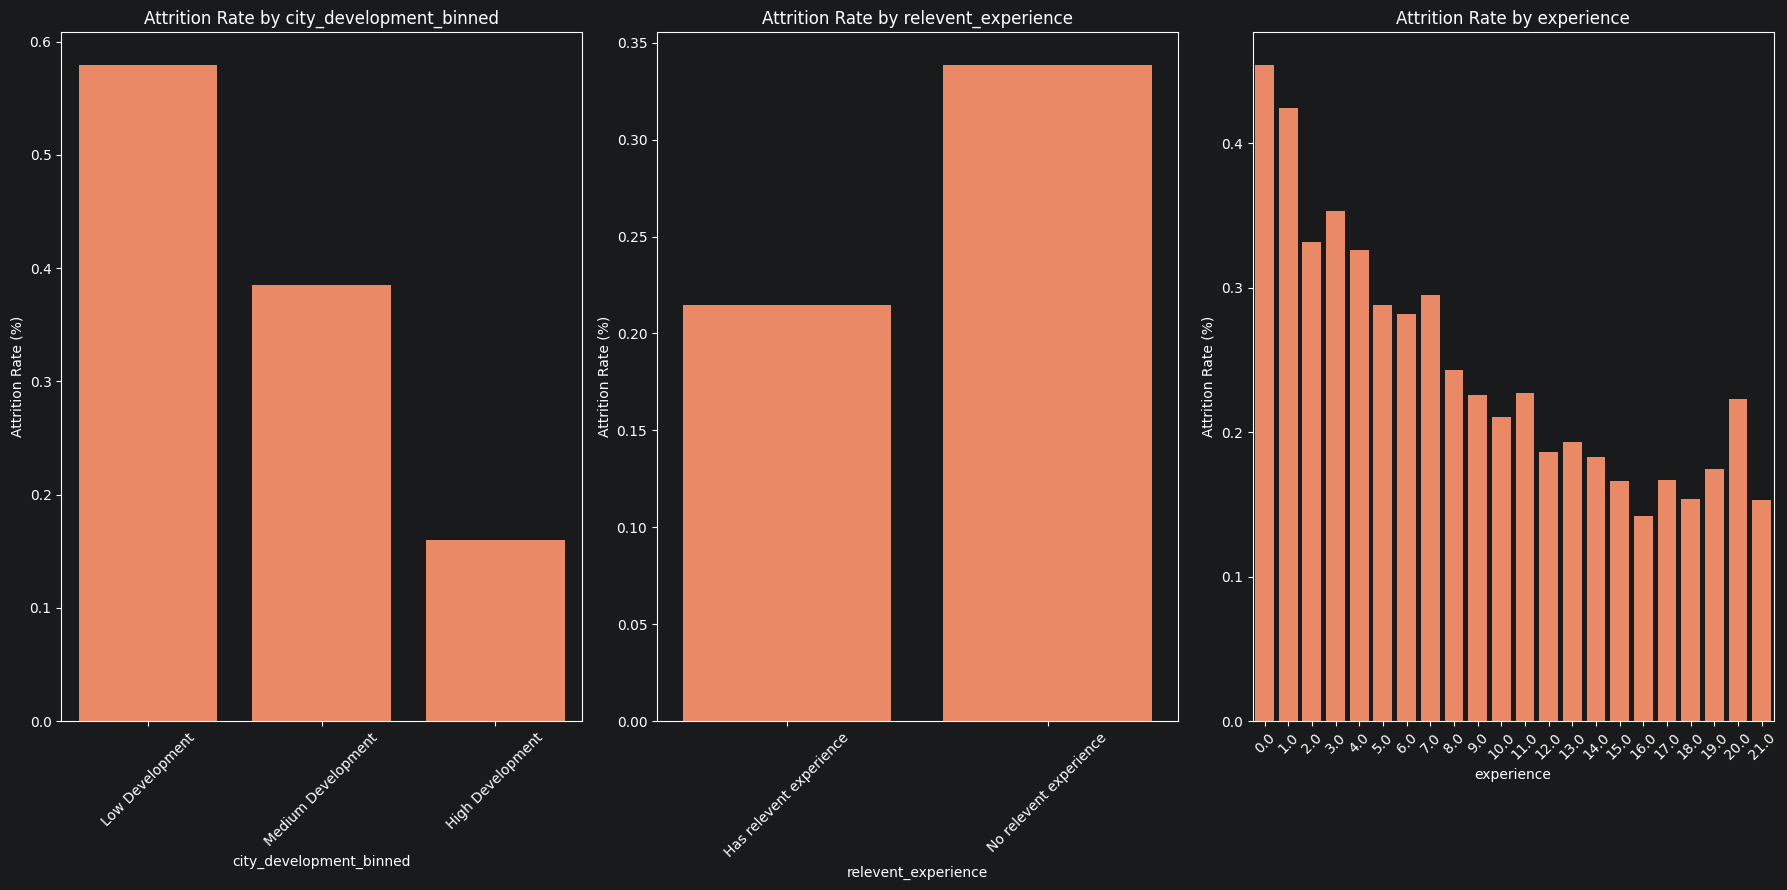

In [27]:
# 1. INSIGHTFUL PLOT: 2D Heatmap of Attrition Rate (Company Size vs. Company Type)
plt.figure(figsize=(12, 8))

pivot = pd.pivot_table(df, values='target', index='company_type', columns='company_size', aggfunc='mean')

# Order the columns so the company sizes read logically from small to large
size_order = ['<10', '10-49', '50-99', '100-500', '500-999', '1000-4999', '5000-9999', '10000+', 'Unknown']
pivot = pivot.reindex(columns=size_order)

sns.heatmap(pivot, annot=True, cmap='Reds', fmt='.1%')
plt.title('Attrition Rate by Company Size and Type', fontsize=14)
plt.xlabel('Company Size')
plt.ylabel('Company Type')
plt.show()


# 2. barplots
fig, axes = plt.subplots(1, 3, figsize=(18, 9))
columns = ["city_development_binned", "relevent_experience", "experience"]

for i, col in enumerate(columns):
    # Using barplot with target on the y-axis calculates the mean (attrition rate) automatically
    sns.barplot(data=df, x=col, y='target', ax=axes[i], color='coral', errorbar=None)
    axes[i].set_title(f'Attrition Rate by {col}')
    axes[i].set_ylabel('Attrition Rate (%)')
    axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

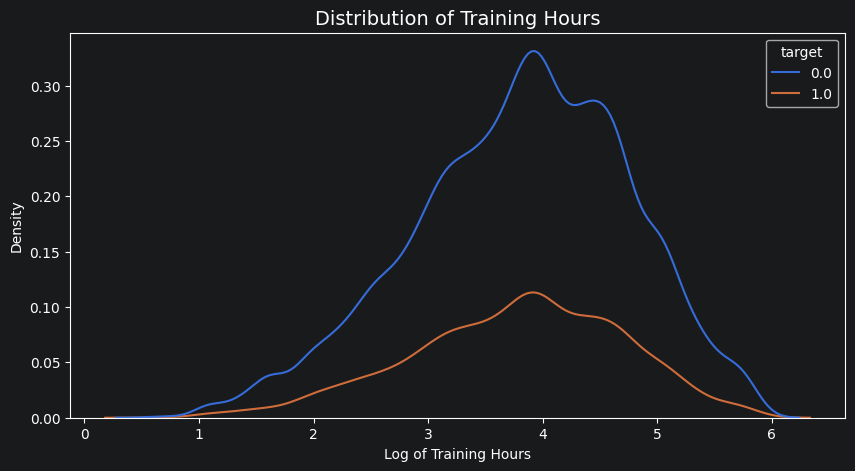

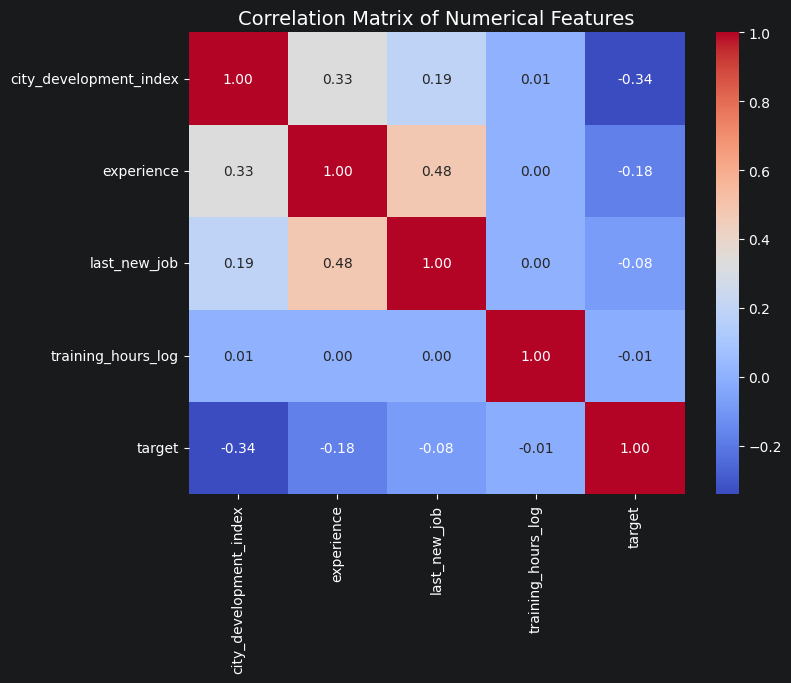

In [29]:
# Kde plot for training
plt.figure(figsize=(10, 5))

sns.kdeplot(data=df, x='training_hours_log', hue='target')
plt.title('Distribution of Training Hours', fontsize=14)
plt.xlabel('Log of Training Hours')
plt.ylabel('Density')
plt.show()


# Numerical Correlation Heatmap
plt.figure(figsize=(8, 6))
num_cols = ['city_development_index', 'experience', 'last_new_job', 'training_hours_log', 'target']

# Calculate correlation and plot
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features', fontsize=14)
plt.show()

# Summary & Insights

Here is what is driving them to leave, and what HR can do about it:

### 1. The Environment is the Biggest Driver (City Development)
* **The Finding:** The `city_development_index` has the strongest negative correlation with attrition. Candidates living in cities with lower development indexes are significantly more likely to look for new jobs.
* **The "Why":** These employees are likely using training programs as a stepping stone to relocate to highly developed cities for better pay and standard of living.

### 2. The Experience Factor
* **The Finding:** Junior to mid-level employees have the highest flight risk. Conversely, senior veterans (with close to 20 years of experience) are highly stable and rarely look for job changes.
* **The "Why":** Junior employees are actively trying to climb the corporate ladder and aggressively chasing salary bumps, while senior employees prioritize stability.

### 3. The Training Paradox
* **The Finding:** Looking at our density plots and correlation matrix, `training_hours` has almost zero correlation with attrition.
* **The "Why":** Giving an employee 100 hours of training does *not* make them more loyal, but it also doesn't cause them to leave. Training is a neutral factor in retention.

### Actionable Recommendations for HR
1. **Targeted Retention Budgets:** HR should stop spreading retention bonuses evenly across the board. The budget should be heavily targeted toward **junior/mid-level employees living in lower-development cities**, as they are the highest flight risk.
2. **Hiring Strategy:** If the company wants long-term loyalty for a specific role, they should prioritize hiring candidates from highly developed cities, or candidates with 15+ years of experience.
3. **Revamp Startup Culture:** If this data applies to an Early Stage Startup, HR needs to investigate culture and compensation, as startups are losing talent at a much higher rate than Public Sector or large Pvt Ltd companies.

# Model Building

In [30]:
from sklearn.model_selection import train_test_split


cols_to_drop = ['city', 'city_development_binned']
ml_df = df.drop(columns=cols_to_drop, errors='ignore')

X = ml_df.drop(columns=['target'])
y = ml_df['target']

categorical_cols = ['gender', 'relevent_experience', 'enrolled_university',
                    'education_level', 'major_discipline', 'company_size', 'company_type']

X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Original dataframe shape: {df.shape}")
print(f"New ML features shape (after encoding): {X_train.shape}")

Original dataframe shape: (19158, 15)
New ML features shape (after encoding): (15326, 36)



--- Classification Report ---
              precision    recall  f1-score   support

         0.0       0.83      0.88      0.86      2877
         1.0       0.56      0.46      0.51       955

    accuracy                           0.78      3832
   macro avg       0.70      0.67      0.68      3832
weighted avg       0.76      0.78      0.77      3832



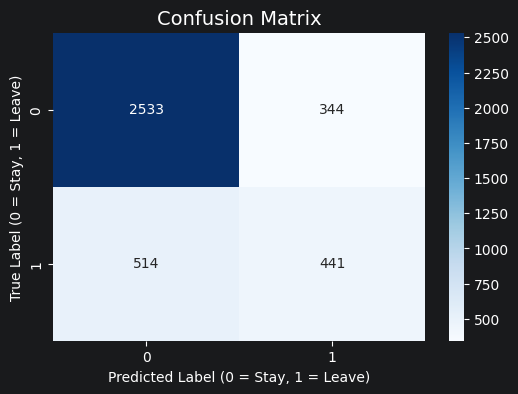

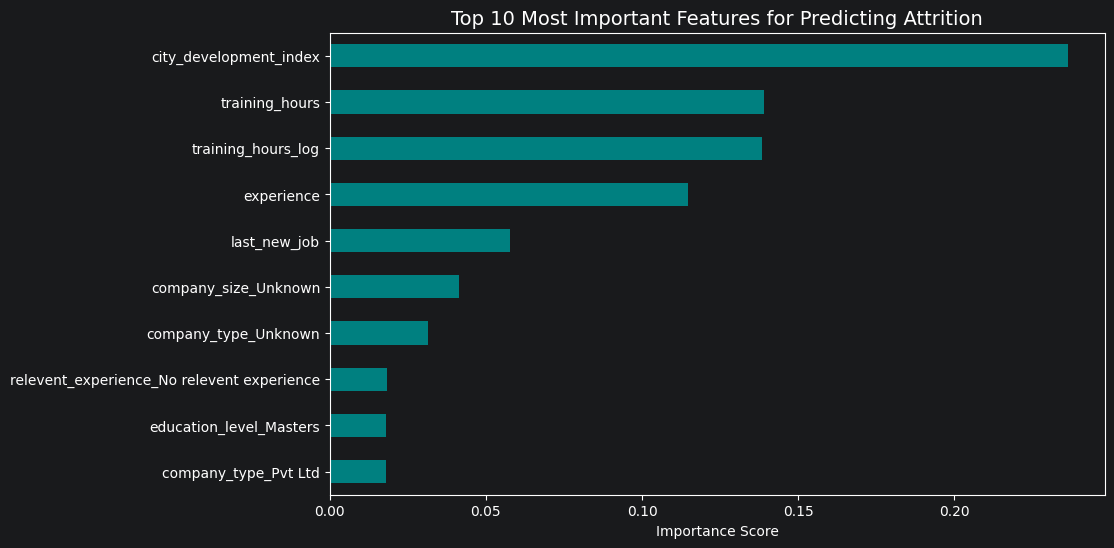

In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label (0 = Stay, 1 = Leave)')
plt.ylabel('True Label (0 = Stay, 1 = Leave)')
plt.show()

# This ranks the exact variables the model found most mathematically useful for predicting job changes
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
plt.figure(figsize=(10, 6))
importances.nlargest(10).sort_values().plot(kind='barh', color='teal')
plt.title('Top 10 Most Important Features for Predicting Attrition', fontsize=14)
plt.xlabel('Importance Score')
plt.show()

--- TUNED Classification Report ---
              precision    recall  f1-score   support

         0.0       0.92      0.76      0.83      2877
         1.0       0.53      0.79      0.63       955

    accuracy                           0.77      3832
   macro avg       0.72      0.78      0.73      3832
weighted avg       0.82      0.77      0.78      3832



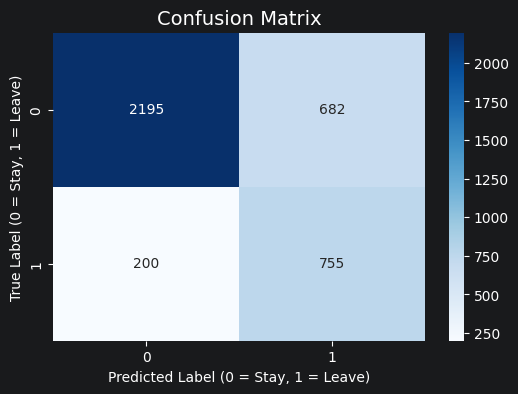

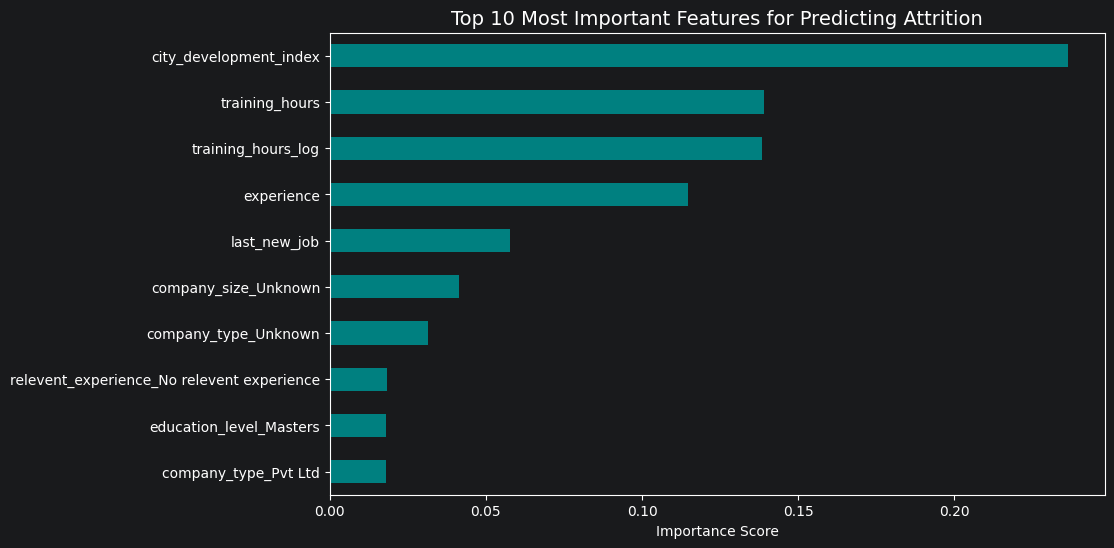

In [34]:
# FIX 1: Pruned Random Forest (Stops Overfitting)
rf_tuned = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,           # Stops the trees from getting too complex and memorizing noise
    min_samples_leaf=10,   # Requires at least 10 similar employees to make a final decision
    class_weight='balanced',
    random_state=42
)

# Train the tuned model
rf_tuned.fit(X_train, y_train)

# Predict and Evaluate
y_pred_tuned = rf_tuned.predict(X_test)

print("--- TUNED Classification Report ---")
print(classification_report(y_test, y_pred_tuned))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_tuned), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label (0 = Stay, 1 = Leave)')
plt.ylabel('True Label (0 = Stay, 1 = Leave)')
plt.show()